# DDP 多卡分布式训练与 All-Reduce

## 1. 什么是 DDP？
DDP (Distributed Data Parallel) 是 PyTorch 中最主流的分布式训练模式。

### 核心逻辑：
- 它为每个 GPU 开启一个独立的进程。
- 每个进程都持有一份完整的模型副本。

### 数据分配：
- 通过 DistributedSampler 将一个 Batch 的数据平分给 $N$ 个 GPU。

### 同步机制：
- 各显卡独立计算梯度，然后通过 All-Reduce 算法进行全局同步，确保更新后的模型参数完全一致。

## 2. 核心通信机制：Ring All-Reduce

### All-Reduce 的目标：
让 $N$ 个 GPU 最终都获得所有梯度之和。为了避免单张主卡带宽被撑爆，它采用了“环形”算法。

### 第一阶段：Reduce-Scatter（规约分发）
这个阶段的目的是计算出每一块数据的总和，但结果分布在不同的卡上。

#### 操作：
1. 将每个 GPU 上的梯度数据切成 $N$ 份。
2. 大家连成一个环（GPU 0 → 1 → 2 → 0）。
3. 循环传递：每个 GPU 向邻居发送一个块，同时接收另一个块并与本地数据相加。

#### 举例（以 3 张卡为例）：
#### 第一步：切分数据 (Chunking)  
##### 为了不让某一个 GPU 承担所有通信压力，我们把每台机器的数据切成 3 份：  
        GPU 0: 拥有数据 $[A_0, A_1, A_2]$  
        GPU 1: 拥有数据 $[B_0, B_1, B_2]$  
        GPU 2: 拥有数据 $[C_0, C_1, C_2]$  
#### 第二步：环形传递 (The Ring)  
##### 我们将这三台机器连成一个环：GPU 0 → GPU 1 → GPU 2 → GPU 0。  
    第一次传递：  
        GPU 0 把自己的 $A_0$ 发给 GPU 1。  
        GPU 1 把自己的 $B_1$ 发给 GPU 2。  
        GPU 2 把自己的 $C_2$ 发给 GPU 0。  
    此时，接收方会立即进行“加法”操作：  
        GPU 1 现在手里的第一块变成了：$A_0 + B_0$  
        GPU 2 现在手里的第二块变成了：$B_1 + C_1$  
        GPU 0 现在手里的第三块变成了：$C_2 + A_2$  
    第二次传递（关键点）：大家把刚刚算好的“半成品”继续传给下一个：  
        GPU 1 把算好的 $(A_0 + B_0)$ 发给 GPU 2。  
        GPU 2 把算好的 $(B_1 + C_1)$ 发给 GPU 0。  
        GPU 0 把算好的 $(C_2 + A_2)$ 发给 GPU 1。  
    再次进行“加法”：  
        GPU 2 的第一块变成了：$(A_0 + B_0) + C_0$  —— （完成！这是第一块的总和）  
        GPU 0 的第二块变成了：$(B_1 + C_1) + A_1$  —— （完成！这是第二块的总和）  
        GPU 1 的第三块变成了：$(C_2 + A_2) + B_2$  —— （完成！这是第三块的总和）  
#### 阶段性成果（Reduce-Scatter 结束）  
    此时的状态非常有意思：  
        GPU 2 拥有全天下最完整的“第 0 块”数据。  
        GPU 0 拥有全天下最完整的“第 1 块”数据。  
        GPU 1 拥有全天下最完整的“第 2 块”数据。



### 第二阶段：All-Gather（全收集）
这个阶段的目的是把散落在各卡上的“真相”同步给所有人。

#### 操作：
- 不再进行加法计算，只进行纯粹的数据搬运。
- 大家把手里那块已经算好的“全量总和”顺着环传给邻居。

#### 举例（以 3 张卡为例）：
- 此时的状态：
  - GPU 0: 拥有完整的第二块 $Sum(1)$
  - GPU 1: 拥有完整的第三块 $Sum(2)$
  - GPU 2: 拥有完整的第一块 $Sum(0)$
- 第一次传递：
  - GPU 0 把 $Sum(1)$ 发给 GPU 1。
  - GPU 1 把 $Sum(2)$ 发给 GPU 2。
  - GPU 2 把 $Sum(0)$ 发给 GPU 0。
  - 此时，每个 GPU 手里都有了两块完整的答案。
- 第二次传递：
  - GPU 0 把刚刚从 GPU 2 那里拿到的 $Sum(0)$ 继续传给 GPU 1。
  - GPU 1 把从 GPU 0 那里拿到的 $Sum(1)$ 传给 GPU 2。
  - GPU 2 把从 GPU 1 那里拿到的 $Sum(2)$ 传给 GPU 0。
- 经过这两轮传递，每个 GPU 都集齐了 $Sum(0), Sum(1), Sum(2)$。
  
  #### 结果：
经过 $N-1$ 次传递：
- 每个 GPU 都集齐了所有分块的最终总和。

## 3. 关于“梯度之和”与“平均”的数学说明

### 实际操作中包含两层平均：
1. **单卡内平均**：
   - Loss 函数通常默认 `reduction='mean'`，所以每张卡算出的梯度已经是其 Local_Batch 的平均值。
2. **多卡间平均**：
   - All-Reduce 算出的是各卡梯度的总和，DDP 在底层会自动将其除以进程总数 (World Size)。

### 公式推导：
$$\text{Final Gradient} = \frac{\text{Grad(GPU 0)} + \text{Grad(GPU 1)} + ...}{N}$$

### 结论：
最终得到的梯度在数学上严格等于全量数据（Global Batch）的全局平均梯度。

## 4. 重点提示：学习率缩放

由于分布式训练本质上是在跑一个巨大的 Batch，梯度的指向会更加稳定（方差变小）。

### 线性缩放规则：
当你把 GPU 数量（以及总 Batch Size）扩大 $N$ 倍时，通常建议同步将学习率 (Learning Rate) 也调大。这样可以更快地收敛，充分发挥多卡并行的优势。

DDP 的标准执行流程如下：

    初始化 ProcessGroup：建立进程间的通信握手。
    广播权重（Broadcast）：训练开始时，Rank 0 节点的模型权重被广播到所有其他节点，确保初始状态一致。
    前向反向传播：每个节点在自己的数据子集上独立计算。
    梯度归约（All-Reduce）：各节点的梯度被汇聚（求和或平均），然后同步回所有节点。
    参数更新：各节点使用同步后的梯度独立更新权重。

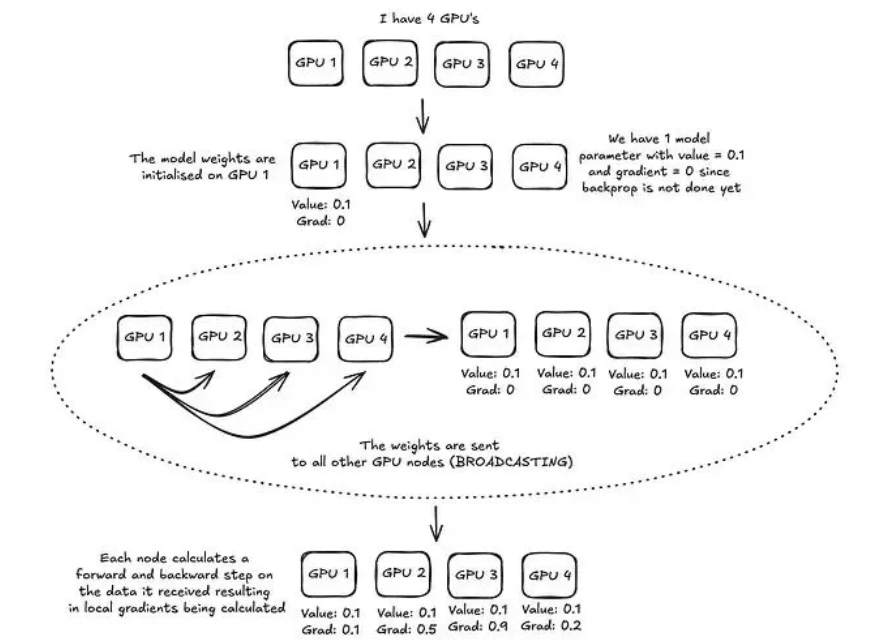
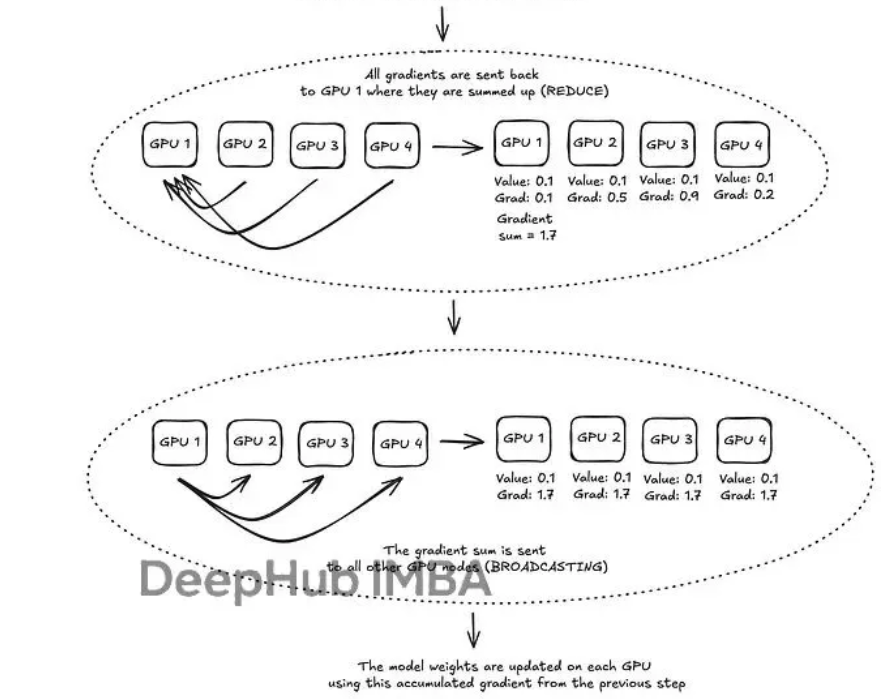

### 计算与通信的重叠（Computation-Communication Overlap）。
这种机制是DDP（DistributedDataParallel）相比于早期的 DP 或朴素同步机制最核心的工程优化。

1. 梯度 Hook：  触发同步的“警报器”  
   在 PyTorch 中，DDP 会为模型的每个参数注册一个 autograd hook（反向传播钩子）。  
   实时触发：在反向传播过程中，一旦某个参数的梯度 $\nabla w$ 计算完成，对应的 Hook 就会被立即触发。  
   无需等待：它不需要等到 loss.backward() 全部执行完，而是边算边触发。这就好比工厂流水线，零件 A 加工完立刻送去质检，而不是等所有零件都加工完再统一质检。
我们可能认为要等所有层的梯度算完再同步，但这会导致 GPU 出现长时间空闲（Wait）。所以DDP 的做法是一旦某层的梯度算出来，如果不被依赖，就立刻发送同步。  
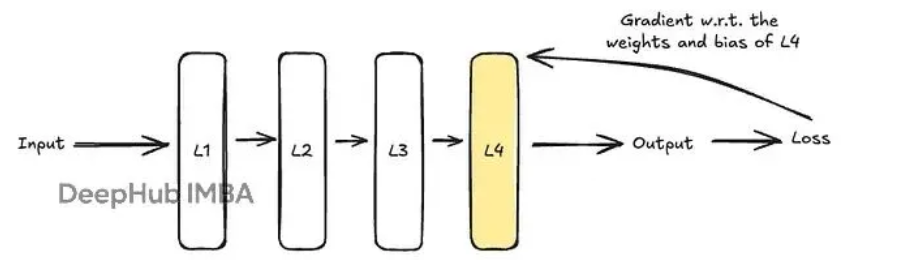  
如上图，Layer 4 的梯度一算好，在计算 Layer 3 的同时，Rank 0 已经在处理 Layer 4 的同步了。

2. 分桶策略 (Gradient Bucketing)
    - 虽然“边算边同步”很高效，但如果每个参数一算完就发一次网络包，会导致严重的网络拥塞（大量小包的包头开销远大于数据本身）。

    - Bucket 的原理：DDP 会将模型的参数按照反向传播的顺序（从最后一层往第一层）倒序排列，并划分成一个个“桶”（默认大小通常为 25MB）。  
    - 等待触发：  
        - 当 Layer 4 的梯度算好了，它先进入 Bucket 1。  
        - 接着 Layer 3 的梯度算好了，也进入 Bucket 1。  
        - 一旦 Bucket 1 被装满（或者所有属于该桶的梯度都到齐了），DDP 才会启动针对这个桶的 All-Reduce。  
    - 逆序排列：由于反向传播是从输出层向输入层进行的，因此 Bucket 的顺序也是从后向前的。通常第一个桶（包含最后几层）会稍微小一点，为了让通信尽早开始。  

这种批量处理大幅降低了通信开销。  
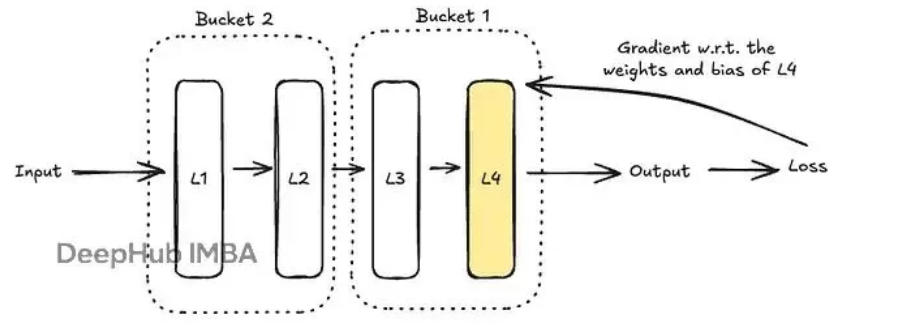

3. 计算与通信的重叠 (Overlap)
    这是 DDP 跑得快的真正秘密。它利用了 GPU 的多流（Multi-stream）特性。

    - 双管齐下：
        - 计算流（Computation Stream）：继续向上计算更浅层的梯度（如 Layer 2, Layer 1）。
        - 通信流（Communication Stream）：在后台利用网卡（NCCL）进行已经填满的 Bucket 的 All-Reduce。
        - 消除空闲：如果通信速度够快，当计算流结束时，大部分梯度的同步已经完成了。GPU 几乎不需要停下来专门等网络传输。

### 下面讲解如何使用


In [1]:
import os
import torch
import torch.nn as nn
# 模拟一个带 EMA 功能的简单包装
class EMAModel:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {name: param.clone().detach() for name, param in model.named_parameters()}

    def update(self):
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                self.shadow[name].data.copy_(self.decay * self.shadow[name].data + (1 - self.decay) * param.data)

 #### EMA（Exponential Moving Average，指数移动平均） 
1. 核心概念：双模型并行在开启 EMA 的训练中，内存里实际上存在两套参数：  
- 在线参数 ($W_{online}$)：由优化器（SGD/Adam）直接更新，负责计算梯度并进行反向传播。
- 影子参数 ($W_{ema}$)：由在线参数通过“滑动平均”计算而来，不参与梯度计算，只负责记录。
2. 数学原理EMA 的更新遵循以下公式：
$$W_{ema}^{(t)} = \text{decay} \times W_{ema}^{(t-1)} + (1 - \text{decay}) \times W_{online}^{(t)}$$
- decay (衰减率)：通常设为 0.999 或 0.9999。
- 含义：影子权重保留了 99.9% 的旧记忆，只吸收 0.1% 的新变化。这使得权重在参数空间中的移动非常平滑。
3. 为什么 EMA 效果更好？  
虽然影子参数在训练时不“带路”，但它通常比在线参数更稳健：
- 平滑噪声：每一个 Batch 的训练都带有随机性（噪声）。优化器会让模型“左右横跳”，而 EMA 像一个低通滤波器，过滤掉了高频震荡，只保留了长期的下降趋势。
- 权重空间集成：从数学上看，EMA 相当于对历史多个 Step 的模型进行了“加权集成”。集成后的权重通常落在 Loss 谷底更平坦、更宽阔的区域。
- 提升泛化性：在线参数容易过拟合当前最新的 Batch，而影子参数因为具有“惯性”，更倾向于代表整个数据集的特征分布。
4. DDP 模式下的工程实现细节在分布式训练代码中，EMA 的实现分为三个关键动作：
- 初始化 (一次性)：在 DDP 包装模型后，通过 model.module.named_parameters() 克隆一份不含梯度的初始权重。必须针对 .module 操作，因为 DDP 本身只是个包装壳。
- 更新 (每 Step 执行)：在 optimizer.step() 完成后，手动遍历参数字典，利用 copy_ 方法原地更新影子权重。由于 DDP 保证了每张卡的在线参数在 step 后是同步的，因此每张卡维护的 EMA 也是同步的。
- 保存与使用 (训练结束)：训练过程中模型依然用在线参数跑。训练结束后，丢弃在线参数，将 ema_params 保存为最终的 .pth 文件。在推理（Inference）阶段，加载这份影子参数。

🛠️ DDP 流程全解析：从必须到进阶  
#### 第一阶段：初始化与环境配置（必须项 🚨）  
1. dist.init_process_group：建立通信网络  
- 作用：让不同 GPU 上的独立进程互相“认识”，建立进程组。  
- 原因：没有它，各卡就是孤岛，无法进行 All-Reduce 同步。  
- 规范：对于 NVIDIA GPU，后端（backend）必须选 nccl。  
2. torch.cuda.set_device(local_rank)：绑定显卡  
- 作用：强制当前进程只使用它被分配到的那张显卡。  
- 原因：如果不绑定，所有进程可能默认抢占 cuda:0，直接导致显存溢出（OOM）。

In [2]:
import torch.distributed as dist

def setup():
    # 规范化：由 torchrun 自动分配环境变量
    dist.init_process_group(backend="nccl")
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    return local_rank


#### 第二阶段：模型包装（必须项 🚨）  
1. model.to(local_rank) 之后再包装 DDP  
- 作用：先将模型搬到对应 GPU，再用 DDP 壳子套住。  
- 原因：DDP 在包装瞬间会执行 Broadcast，确保所有卡上的初始参数完全一致。如果参数起跑线不同，All-Reduce 算出来的梯度也是废的。
2. 分桶优化（锦上添花 ✨）  
- 参数：DDP(model, bucket_cap_mb=25)。  
- 作用：这就是我们聊过的“打包发送”。25MB 是平衡通信频率和带宽利用率的经验值。如果你的模型特别小，调小这个值可以更早触发同步；如果带宽很贵，调大它可以减少包头开销。  

In [3]:
from torch.nn.parallel import DistributedDataParallel as DDP

def model_wrap(model, local_rank):
    # 规范化：DDP 包装
    model = model.to(local_rank)
    model = DDP(model, device_ids=[local_rank], output_device=local_rank)
    # 锦上添花：调整通信参数bucket_cap_mb，减少小张量通信的开销
    # model =DDP(model, device_ids=[local_rank], output_device=local_rank,bucket_cap_mb=64) 
    return model

#### 第三阶段：数据加载（必须项 🚨）
1. DistributedSampler：切分蛋糕  
- 作用：确保每张卡拿到不同的数据子集。  
- 原因：如果不加这个，每张卡都在跑同样的 Batch，这不叫分布式，这叫“重复劳动”，还会导致 Loss 异常。
2. sampler.set_epoch(epoch)：洗牌同步  
- 作用：每一轮训练前重新打乱数据分布。
- 原因：这是最容易漏掉的必须操作。如果不写，模型每轮见到的数据顺序都是一样的，这会极大地损害模型的泛化能力，甚至导致不收敛。

In [4]:
from torch.utils.data import DataLoader, DistributedSampler, Dataset

# 1. 定义一个简单的线性回归模型
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

# 2. 准备数据
class RegressionDataset(Dataset):
    def __init__(self):
        self.x = torch.randn(1000, 1)
        self.y = 3.5 * self.x + 0.8  # 目标函数 y = 3.5x + 0.8

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    
def data_process():
    dataset = RegressionDataset()
    # 规范化：使用 DistributedSampler 来分配数据
    sampler = DistributedSampler(dataset)
    dataloader = DataLoader(dataset, batch_size=32, sampler=sampler)
    return dataloader

#### 第四阶段：训练循环（进阶逻辑）  
1. loss.backward() 与计算通信重叠（必须项原理 🚨）
- 作用：这是 DDP 的灵魂。
- 原理：你不需要在代码里写任何额外的东西，只要用了 DDP 包装模型，这一步就会自动实现边算边传。
2. 梯度裁剪 clip_grad_norm_（锦上添花 ✨）
- 作用：防止梯度爆炸。
- 注意：在 DDP 中，必须针对 model.parameters() 进行裁剪。虽然不裁剪可能也能跑，但在多卡大 Batch 下，模型极易由于学习率波动而跑飞，这是工业级的稳定性保障。
3. EMA（指数移动平均）（锦上添花 ✨）
- 作用：让模型权重更平滑，通常能提升 1%-2% 的精度。
- 规范：EMA 状态通常只存在于本地，保存时只需主进程保存一份即可。

In [ ]:
import os
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, DistributedSampler, Dataset

# === 1. 基础组件 ===
class SimpleDataset(Dataset):
    def __init__(self):
        # 模拟数据
        self.x = torch.randn(1000, 1)
        self.y = 3.5 * self.x + 0.8
    def __len__(self): return 1000
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x): return self.linear(x)

# === 2. 核心训练函数 ===
def train():
    # --- [第一阶段：分布式环境初始化] ---
    
    # 获取由 torchrun 注入的环境变量 (必须 🚨)
    # rank: 全局进程编号；local_rank: 当前机器显卡编号；world_size: 总卡数
    rank = int(os.environ["RANK"])
    local_rank = int(os.environ["LOCAL_RANK"])
    world_size = int(os.environ["WORLD_SIZE"])

    # 初始化进程组 (必须 🚨)
    # backend="nccl" 是 NVIDIA GPU 训练的唯一标准后端
    dist.init_process_group(backend="nccl") 
    
    # 绑定当前进程到指定的显卡 (必须 🚨)
    # 否则所有进程都会默认抢 GPU 0，导致显存溢出 (OOM)
    torch.cuda.set_device(local_rank)      
    
    # 设置同步屏障 (锦上添花 ✨)
    # 确保所有显卡都初始化完成了才开始下面的步骤，防止进度不一导致超时报错
    dist.barrier()                         

    # --- [第二阶段：数据分发配置] ---
    
    dataset = SimpleDataset()
    
    # 实例化分布式采样器 (必须 🚨)
    # 它的作用是将 1000 条数据平分给 world_size 张卡，确保每张卡拿到的数据不重复
    sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank)
    
    # 绑定采样器到 DataLoader (必须 🚨)
    # 注意：使用 sampler 时，DataLoader 的 shuffle 必须为 False (由 sampler 负责 shuffle)
    dataloader = DataLoader(dataset, batch_size=32, sampler=sampler)

    # --- [第三阶段：模型包装] ---
    
    # 先把模型搬到对应的 GPU 上 (必须 🚨)
    model = LinearModel().to(local_rank)
    
    # 用 DDP 包装模型 (必须 🚨)
    # 原理：DDP 会在初始化时同步所有卡的模型参数，并在 backward 时自动触发 All-Reduce
    # device_ids 指定当前进程负责的那张卡
    model = DDP(model, device_ids=[local_rank]) 
    
    # EMA 初始化 (锦上添花 ✨)
    # 指数移动平均能让训练更平滑，提高模型鲁棒性
    # 必须针对 model.module（原始模型）提取参数，因为 DDP 是一个包装壳
    ema_decay = 0.999
    ema_params = {name: p.clone().detach() for name, p in model.module.named_parameters()}
    
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    # --- [第四阶段：训练循环] ---
    
    for epoch in range(10):
        # 设置采样器的 epoch (必须 🚨)
        # 极其重要！如果不设，每一轮训练数据被洗牌后的顺序都是一样的，会导致过拟合
        sampler.set_epoch(epoch) 
        
        for x, y in dataloader:
            # 数据搬运到 GPU (必须 🚨)
            x, y = x.to(local_rank), y.to(local_rank)
            
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            
            # 执行反向传播 (必须逻辑 🚨)
            # DDP 原理：此步骤会触发 "梯度重叠通信" (Gradient Bucketing)
            # 在计算后面层的梯度时，前面已经算好的梯度已经开始在后台进行跨卡同步了
            loss.backward()
            
            # 梯度裁剪 (锦上添花 ✨)
            # 防止多卡同步后梯度过大（梯度爆炸），这是大模型训练的保命手段
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # 更新参数 (必须 🚨)
            # 此处会阻塞，直到所有进程的梯度 All-Reduce 全部完成
            optimizer.step()

            # 更新 EMA 影子参数 (锦上添花 ✨)
            with torch.no_grad():
                for name, p in model.module.named_parameters():
                    ema_params[name].copy_(ema_decay * ema_params[name] + (1.0 - ema_decay) * p)

        # --- [第五阶段：日志聚合] ---
        
        # 损失聚合 (锦上添花 ✨)
        # loss 只在当前卡上，通过 all_reduce 把所有卡的 loss 相加，再除以总卡数得到平均 Loss
        avg_loss = loss.detach().clone()
        dist.all_reduce(avg_loss, op=dist.ReduceOp.SUM)
        
        # 只让主进程（rank 0）打印日志 (必须 🚨)
        # 否则终端会同时弹出 N 倍的重复日志，非常混乱
        if rank == 0:
            print(f"Epoch {epoch} | Avg Loss: {avg_loss.item()/world_size:.4f}")

    # --- [第六阶段：保存与清理] ---
    
    # 仅由主进程负责保存模型 (必须 🚨)
    if rank == 0:
        # 保存 EMA 权重通常比保存原始权重在推理阶段更有效
        torch.save(ema_params, "ema_model.pth")
    
    # 销毁进程组，释放通信资源 (必须 🚨)
    dist.destroy_process_group()

if __name__ == "__main__":
    train()

#### 第五阶段：日志与保存（必须项 🚨）
1. if global_rank == 0：权力集中
- 作用：只有主进程负责打印、保存 Checkpoint、上传 WandB。
- 原因：必须做！否则 $N$ 张卡同时写同一个文件，轻则文件损坏，重则程序死锁。
2. dist.all_reduce 损失聚合（锦上添花 ✨）
- 作用：让展示出的 Loss 是所有卡的总和平均。
- 原因：不影响模型训练（因为梯度已经同步了），但如果你不聚合，你看到的 Loss 只是其中一张卡的，波动会比较大，不利于你监控模型是否训练正常。

启动不能用python train.py  
必须用torchrun,建议是写一个shell脚本一键启动  
现在是在notebook里，不能直接启动，但是可以用下面的方法，先用writefile写进.py文件，然后调用

In [10]:
%%writefile ddp_train_script.py
import os
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, DistributedSampler, Dataset

# === 1. 基础组件 ===
class SimpleDataset(Dataset):
    def __init__(self):
        # 模拟数据
        self.x = torch.randn(1000, 1)
        self.y = 3.5 * self.x + 0.8
    def __len__(self): return 1000
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x): return self.linear(x)

# === 2. 核心训练函数 ===
def train():
    # --- [第一阶段：分布式环境初始化] ---
    
    # 获取由 torchrun 注入的环境变量 (必须 🚨)
    # rank: 全局进程编号；local_rank: 当前机器显卡编号；world_size: 总卡数
    rank = int(os.environ["RANK"])
    local_rank = int(os.environ["LOCAL_RANK"])
    world_size = int(os.environ["WORLD_SIZE"])

    # 初始化进程组 (必须 🚨)
    # backend="nccl" 是 NVIDIA GPU 训练的唯一标准后端
    dist.init_process_group(backend="nccl") 
    
    # 绑定当前进程到指定的显卡 (必须 🚨)
    # 否则所有进程都会默认抢 GPU 0，导致显存溢出 (OOM)
    torch.cuda.set_device(local_rank)      
    
    # 设置同步屏障 (锦上添花 ✨)
    # 确保所有显卡都初始化完成了才开始下面的步骤，防止进度不一导致超时报错
    dist.barrier()                         

    # --- [第二阶段：数据分发配置] ---
    
    dataset = SimpleDataset()
    
    # 实例化分布式采样器 (必须 🚨)
    # 它的作用是将 1000 条数据平分给 world_size 张卡，确保每张卡拿到的数据不重复
    sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank)
    
    # 绑定采样器到 DataLoader (必须 🚨)
    # 注意：使用 sampler 时，DataLoader 的 shuffle 必须为 False (由 sampler 负责 shuffle)
    dataloader = DataLoader(dataset, batch_size=32, sampler=sampler)

    # --- [第三阶段：模型包装] ---
    
    # 先把模型搬到对应的 GPU 上 (必须 🚨)
    model = LinearModel().to(local_rank)
    
    # 用 DDP 包装模型 (必须 🚨)
    # 原理：DDP 会在初始化时同步所有卡的模型参数，并在 backward 时自动触发 All-Reduce
    # device_ids 指定当前进程负责的那张卡
    model = DDP(model, device_ids=[local_rank]) 
    
    # EMA 初始化 (锦上添花 ✨)
    # 指数移动平均能让训练更平滑，提高模型鲁棒性
    # 必须针对 model.module（原始模型）提取参数，因为 DDP 是一个包装壳
    ema_decay = 0.999
    ema_params = {name: p.clone().detach() for name, p in model.module.named_parameters()}
    
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    # --- [第四阶段：训练循环] ---
    
    for epoch in range(10):
        # 设置采样器的 epoch (必须 🚨)
        # 极其重要！如果不设，每一轮训练数据被洗牌后的顺序都是一样的，会导致过拟合
        sampler.set_epoch(epoch) 
        
        for x, y in dataloader:
            # 数据搬运到 GPU (必须 🚨)
            x, y = x.to(local_rank), y.to(local_rank)
            
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            
            # 执行反向传播 (必须逻辑 🚨)
            # DDP 原理：此步骤会触发 "梯度重叠通信" (Gradient Bucketing)
            # 在计算后面层的梯度时，前面已经算好的梯度已经开始在后台进行跨卡同步了
            loss.backward()
            
            # 梯度裁剪 (锦上添花 ✨)
            # 防止多卡同步后梯度过大（梯度爆炸），这是大模型训练的保命手段
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            # 更新参数 (必须 🚨)
            # 此处会阻塞，直到所有进程的梯度 All-Reduce 全部完成
            optimizer.step()

            # 更新 EMA 影子参数 (锦上添花 ✨)
            with torch.no_grad():
                for name, p in model.module.named_parameters():
                    ema_params[name].copy_(ema_decay * ema_params[name] + (1.0 - ema_decay) * p)

        # --- [第五阶段：日志聚合] ---
        
        # 损失聚合 (锦上添花 ✨)
        # loss 只在当前卡上，通过 all_reduce 把所有卡的 loss 相加，再除以总卡数得到平均 Loss
        avg_loss = loss.detach().clone()
        dist.all_reduce(avg_loss, op=dist.ReduceOp.SUM)
        
        # 只让主进程（rank 0）打印日志 (必须 🚨)
        # 否则终端会同时弹出 N 倍的重复日志，非常混乱
        if rank == 0:
            print(f"Epoch {epoch} | Avg Loss: {avg_loss.item()/world_size:.4f}")

    # --- [第六阶段：保存与清理] ---
    
    # 仅由主进程负责保存模型 (必须 🚨)
    if rank == 0:
        # 保存 EMA 权重通常比保存原始权重在推理阶段更有效
        torch.save(ema_params, "ema_model.pth")
    
    # 销毁进程组，释放通信资源 (必须 🚨)
    dist.destroy_process_group()

if __name__ == "__main__":
    train()

Writing ddp_train_script.py


可以直接在notebook里运行，前提是先运行上面单元格的代码

In [11]:
# 假设你有 1 张或 2 张卡，修改 nproc_per_node 即可
!torchrun --nproc_per_node=1 --standalone ddp_train_script.py

[rank0]:[W429 23:42:59.642374071 ProcessGroupNCCL.cpp:4115] [PG ID 0 PG GUID 0 Rank 0]  using GPU 0 to perform barrier as devices used by this process are currently unknown. This can potentially cause a hang if this rank to GPU mapping is incorrect.Specify device_ids in barrier() to force use of a particular device,or call init_process_group() with a device_id.
Epoch 0 | Avg Loss: 5.9771
Epoch 1 | Avg Loss: 8.3701
Epoch 2 | Avg Loss: 6.9785
Epoch 3 | Avg Loss: 10.5455
Epoch 4 | Avg Loss: 1.7400
Epoch 5 | Avg Loss: 2.8957
Epoch 6 | Avg Loss: 0.5312
Epoch 7 | Avg Loss: 0.8022
Epoch 8 | Avg Loss: 0.2234
Epoch 9 | Avg Loss: 0.0253


上面的文件写好之后，如果要用shell脚本来启动，配置方法如下：

In [ ]:
#!/bin/bash

# ==============================================================================
# 1. 硬件可见性配置 (必须项 🚨)
# ==============================================================================
# 作用：定义哪些 GPU 对当前任务可见。
# 必需：是。如果不设，所有进程会默认抢占物理 GPU 0 导致显存溢出 (OOM)。
# 映射关系：这里设置 0,1，则 Python 里的 local_rank 0=物理卡0，local_rank 1=物理卡1。
export CUDA_VISIBLE_DEVICES=0,1

# ==============================================================================
# 2. 自动计算进程总数 (必须项 🚨)
# ==============================================================================
# 作用：计算参与训练的 GPU 总数，用于传给 --nproc_per_node 参数。
# 必需：是。DDP 标准模式是 1个进程控制 1张显卡。
GPU_COUNT=$(echo $CUDA_VISIBLE_DEVICES | tr "," "\n" | wc -l)

# ==============================================================================
# 3. 关于 RANK / WORLD_SIZE / MASTER 配置的特殊说明 (重点 💡)
# ==============================================================================
# 注意：你不需要在这里手动 export RANK 或 WORLD_SIZE。
# 原因：下面的 `torchrun` 工具会自动执行以下隐式逻辑：
#   - 自动生成 WORLD_SIZE：等于 GPU_COUNT * nnodes。
#   - 自动分配 RANK：为派生出的每个 Python 进程分配唯一的全局 0, 1, 2...
#   - 自动分配 LOCAL_RANK：为当前机器上的进程分配本地显卡编号。
#   - 自动设置 MASTER_ADDR/PORT：因为使用了 --standalone，它会自建主节点并寻找空余端口。
# 这些变量会被 `torchrun` 直接注入到 Python 的 os.environ 中。
# ==============================================================================

# ==============================================================================
# 4. NCCL 通信底层优化 (锦上添花 ✨)
# ==============================================================================
# [NCCL_IB_DISABLE] 必需：建议设为1。禁用 IB 通信，防止在普通以太网服务器上因寻找硬件而卡死。
export NCCL_IB_DISABLE=1

# [NCCL_P2P_DISABLE] 必需：建议设为0。允许 GPU 之间通过 PCIe 直接通信，不经过 CPU 内存，速度最快。
export NCCL_P2P_DISABLE=0

# [NCCL_DEBUG] 调试开关。设为 INFO 可以看到详细的握手过程，确认多卡是否连通。
export NCCL_DEBUG=WARN

# ==============================================================================
# 5. 性能监控与框架配置 (锦上添花 ✨)
# ==============================================================================
# [TORCH_LOGS] 监控 PyTorch 2.0 编译行为，发现 recompiles 可排查动态形状导致的卡顿。
export TORCH_LOGS="dynamic,recompiles"
# [HYDRA_FULL_ERROR] 强制打印 Hydra 框架的完整错误堆栈，防止分布式报错被吞。
export HYDRA_FULL_ERROR=1
# [WANDB_API_KEY] 设为 null 强制禁用 WandB 联网，防止在无网环境下启动失败。
export WANDB_API_KEY=null

# ==============================================================================
# 6. 启动器执行 (核心指令 🚨)
# ==============================================================================
# --nproc_per_node: 一台机器起几个进程 (通常 = GPU数)。
# --nnodes: 参与训练的机器总数 (单机训练设为 1)。
# --standalone: 单机模式，自动处理主节点地址和端口，解决“端口占用”报错的利器。
# --max_restarts: 容错机制。如果某个进程崩溃，自动重启任务的次数。
# 注意，这种启动方式必须先激活需要使用的 conda 环境，因为它会使用当前环境的 python 解释器。

echo ">>> 正在启动 DDP 训练，检测到 GPU 数量: $GPU_COUNT"

torchrun \
    --nproc_per_node=$GPU_COUNT \
    --nnodes=1 \
    --standalone \
    --max_restarts=3 \
    ddp_train_script.py

# ==============================================================================
# 7. 分布式启动指令 (核心执行器 🚨)
# ==============================================================================
# 使用 `python -m torch.distributed.run` 替代 torchrun 以确保环境百分之百对齐。
# 好处是可以直接指定conda环境的python解释器，不用先激活conda环境。
# 其他方面与上面 torchrun 的参数完全相同。

python -m torch.distributed.run \
    --nproc_per_node=$GPU_COUNT \
    --nnodes=1 \
    --standalone \
    --max_restarts=3 \
    ddp_train_script.py 